# Loadd Data

In [2]:
import pandas as pd



data = pd.read_csv(r"D:\Sem 4\MLOps\Mg_6\pemodelan sementara\data\clean_data.csv")
data.head()

,order_id,order_status,customer,order_date,order_quantity,sales,discount,discount_value,product_category,product_sub_category
0,3,Order Finished,Muhammed Mac Intyre,2010-10-13,6,523080,0.04,20923,Office Supplies,Storage & Organization
1,293,Order Finished,Barry French,2012-10-01,49,20246040,0.07,1417223,Office Supplies,Appliances
2,483,Order Finished,Clay Rozendal,2011-07-10,30,9931519,0.08,794522,Technology,Telephones & Communication
3,515,Order Finished,Carlos Soltero,2010-08-28,19,788540,0.08,63083,Office Supplies,Appliances
4,613,Order Finished,Carl Jackson,2011-06-17,12,187080,0.03,5612,Office Supplies,Binders & Binder Accessories


# Cek Missing 

In [3]:
misdata = data.isnull().sum()
print(misdata)

order_id                0
order_status            0
customer                0
order_date              0
order_quantity          0
sales                   0
discount                0
discount_value          0
product_category        0
product_sub_category    0
dtype: int64


# produk 
##### LUREHOLIC Rak Holder Joran Pancing Wall Mount Fishing Rod 6 Slot - R5 / Rak Pancing Dinding


In [4]:
produk = data[data["product_sub_category"] == "Appliances"]

In [5]:
produk["order_date"] = pd.to_datetime(produk["order_date"])
produk["date"] = produk["order_date"].sort_values()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1204\1491976946.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produk["order_date"] = pd.to_datetime(produk["order_date"])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_1204\1491976946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produk["date"] = produk["order_date"].sort_values()


# target forecasting

In [6]:
weekly_sales = (
    produk
    .set_index("order_date")
    .resample("W")["order_quantity"]
    .sum()
)

In [7]:
print(weekly_sales.describe())

count    208.000000
mean      44.750000
std       37.861877
min        0.000000
25%       14.000000
50%       38.500000
75%       66.000000
max      166.000000
Name: order_quantity, dtype: float64


# visualisasi Time series

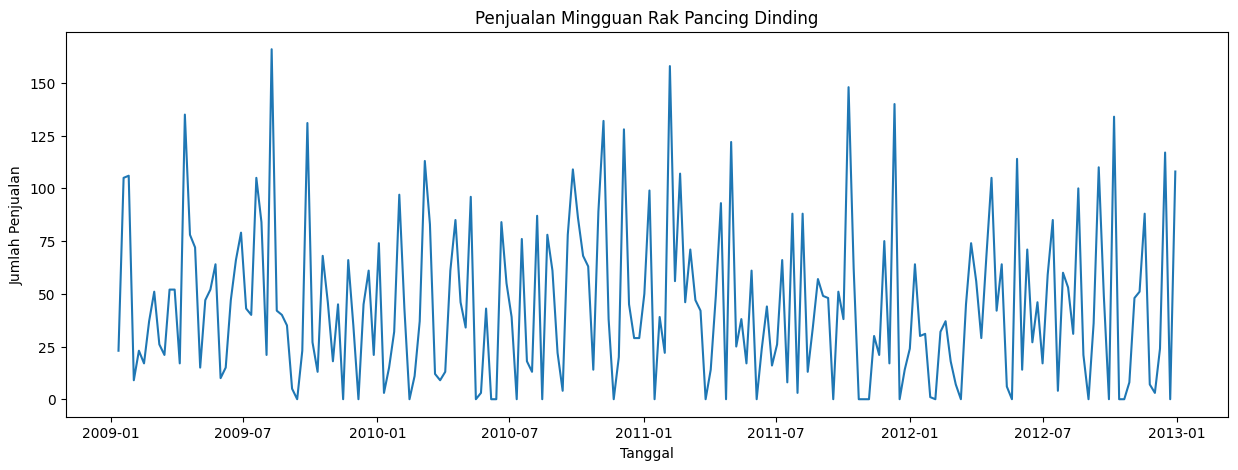

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(weekly_sales)

plt.title("Penjualan Mingguan Rak Pancing Dinding")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Penjualan")

plt.show()

In [9]:
print(len(weekly_sales))


208


# Split Train Test

In [10]:
train_size = int(len(weekly_sales) * 0.8)

train = weekly_sales[:train_size]
test = weekly_sales[train_size:]

In [11]:
print(len(train))
print(len(test))

166
42


# Setup PyCaret

In [12]:
from pycaret.time_series import *

s = setup(
    data=train,
    fh=4,
    fold=2,
    session_id=123,
    seasonal_period=4,
    verbose=True
)


,Description,Value
0,session_id,123
1,Target,order_quantity
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(166, 1)"
5,Transformed data shape,"(166, 1)"
6,Transformed train set shape,"(162, 1)"
7,Transformed test set shape,"(4, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


# Compare model

In [13]:
best_model = compare_models()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.4067,0.3945,17.5394,21.7319,16902267432632012.0000,0.7024,-1.5975,0.3000
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.4333,0.3863,18.7348,21.3326,1387135253603460.7500,0.9055,-0.6530,0.2300
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.4648,0.4213,20.0956,23.2570,21108474474937096.0000,0.8030,-1.0289,0.1450
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,0.5218,0.4537,22.5449,25.0441,11579841840211726.0000,0.8601,-1.4135,1.3800
croston,Croston,0.5350,0.4680,23.1346,25.8403,22609153304135708.0000,0.8547,-1.4611,0.0300
polytrend,Polynomial Trend Forecaster,0.5532,0.4779,23.9098,26.3801,24089195765305676.0000,0.8612,-1.6667,0.0400
exp_smooth,Exponential Smoothing,0.5532,0.4779,23.9098,26.3801,24089228561410500.0000,0.8612,-1.6667,0.0600
ets,ETS,0.5532,0.4779,23.9097,26.3800,24089172056994356.0000,0.8612,-1.6667,0.0600
theta,Theta Forecaster,0.5535,0.4781,23.9259,26.3928,24108742278948052.0000,0.8614,-1.6697,0.0550
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.5562,0.4802,24.0430,26.5055,24180013262166308.0000,0.8632,-1.6917,0.1450


# Tuning Model

In [14]:
tuned_model = tune_model(best_model)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2011-12-12/2011-12-18,0.3253,0.3424,14.1484,19.0058,0.4697,0.4241,-0.0233
1,2012-01-09/2012-01-15,0.3607,0.3411,15.5129,18.7560,29331708394791832.0000,1.0517,-0.4627
Mean,NaT,0.3430,0.3417,14.8306,18.8809,14665854197395916.0000,0.7379,-0.2430
SD,NaT,0.0177,0.0006,0.6823,0.1249,14665854197395916.0000,0.3138,0.2197


Fitting 2 folds for each of 10 candidates, totalling 20 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    3.9s finished


# Evaluasi

In [15]:
# Forecast Plot
plot_model(tuned_model, plot="forecast")

In [16]:
# Residual
plot_model(tuned_model, plot="residuals")

In sample predictions has not been implemented for this estimator of type 'BaseCdsDtForecaster' in `sktime`. When this is implemented, it will be enabled by default in pycaret.
In sample predictions has not been implemented for this estimator of type 'BaseCdsDtForecaster' in `sktime`. When this is implemented, it will be enabled by default in pycaret.


# Prediksi

In [17]:
future = predict_model(tuned_model, fh=1)

print(future)

                        y_pred
2012-02-13/2012-02-19  18.9087


# Evaluasi Error

In [18]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test[:1],
    future
)

print("MAE:", mae)

MAE: 26.0913


# Finalisasi Model

In [19]:
final_model = finalize_model(tuned_model)

# Save Model

In [20]:
save_model(final_model, "best_model_produk_p003")

Transformation Pipeline and Model Successfully Saved


(ForecastingPipeline(steps=[('forecaster',
                             TransformedTargetForecaster(steps=[('model',
                                                                 ForecastingPipeline(steps=[('forecaster',
                                                                                             TransformedTargetForecaster(steps=[('model',
                                                                                                                                 BaseCdsDtForecaster(degree=6,
                                                                                                                                                     fe_target_rr=[WindowSummarizer(lag_feature={'lag': [1]},
                                                                                                                                                                                    n_jobs=1)],
                                                                                 